In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install lightgbm joblib

In [ ]:
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
from scipy.sparse import hstack, csr_matrix


In [ ]:
RANDOM_STATE = 42

EXPERIMENT_NAME = "tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1"

BASE_DIR = "/content/drive/MyDrive/CS114/TeamModel"
DATA_DIR = os.path.join(BASE_DIR, "data")

TRAIN_PATH = os.path.join(DATA_DIR, "train_clean_tokenizedEmoji.csv")
VAL_PATH = os.path.join(DATA_DIR, "val_clean_tokenizedEmoji.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_clean_tokenizedEmoji.csv")

ARTIFACT_ROOT = os.path.join(BASE_DIR, "experiments", EXPERIMENT_NAME)
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
REPORT_DIR = os.path.join(ARTIFACT_ROOT, "reports")
ERROR_DIR = os.path.join(ARTIFACT_ROOT, "errors")
FIGURE_DIR = os.path.join(ARTIFACT_ROOT, "figures")

for d in [ARTIFACT_ROOT, CHECKPOINT_DIR, REPORT_DIR, ERROR_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

N_SPLITS = 3
DROP_CROSS_SPLIT_DUPLICATES = True

FEATURE_K = 35000

WORD_NGRAM_RANGE = (1, 3)
CHAR_ANALYZER = "char_wb"
CHAR_NGRAM_RANGE = (3, 5)

WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 30000
WORD_MIN_DF = 3
CHAR_MIN_DF = 3

FORCE_TRAIN = False
FORCE_DECISION_TUNE = False

BASE_MODEL_SETTING = "default"

META_C = 1.0
META_CLASS_WEIGHT = "balanced"

LEXICON_FEATURES = [
    "depression_keyword_count",
    "suicide_keyword_count",
]

DEPRESSION_KEYWORDS = [
    "depress", "sad", "hopeless", "worthless", "empty",
    "cry", "lonely", "tired", "pain", "numb"
]

SUICIDE_KEYWORDS = [
    "suicide", "suicidal", "kill myself", "kms", "kys", "end my life",
    "want to die", "wanna die", "die", "death", "overdose", "jump",
    "cut", "hurt myself", "hang myself"
]

OOF_TRAIN_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_train.npy")
OOF_VAL_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_val.npy")
OOF_TEST_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_test.npy")

FOLD_BUNDLE_PATHS = [
    os.path.join(
        CHECKPOINT_DIR,
        f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib"
    )
    for fold_idx in range(1, N_SPLITS + 1)
]

META_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__meta_logistic_model.joblib"
)

WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__class_decision_weights.json"
)

CONFIG_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__config.json"
)

config = {
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "N_SPLITS": N_SPLITS,
    "DROP_CROSS_SPLIT_DUPLICATES": DROP_CROSS_SPLIT_DUPLICATES,
    "FEATURE_K": FEATURE_K,
    "CHI2_APPLIED_TO": "tfidf_features_only",
    "WORD_NGRAM_RANGE": WORD_NGRAM_RANGE,
    "CHAR_ANALYZER": CHAR_ANALYZER,
    "CHAR_NGRAM_RANGE": CHAR_NGRAM_RANGE,
    "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
    "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
    "WORD_MIN_DF": WORD_MIN_DF,
    "CHAR_MIN_DF": CHAR_MIN_DF,
    "BASE_MODEL_SETTING": BASE_MODEL_SETTING,
    "BASE_MODELS": {
        "svm": "CalibratedClassifierCV(estimator=LinearSVC())",
        "cnb": "ComplementNB()",
        "lgb": "LGBMClassifier()"
    },
    "META_C": META_C,
    "META_CLASS_WEIGHT": META_CLASS_WEIGHT,
    "TUNING_MODE": "decision_weight_only",
    "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
    "LEXICON_FEATURES": LEXICON_FEATURES,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Experiment:", EXPERIMENT_NAME)
print("Artifact root:", ARTIFACT_ROOT)
print(json.dumps(config, indent=2, ensure_ascii=False))

Experiment: tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1
Artifact root: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1
{
  "EXPERIMENT_NAME": "tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1",
  "N_SPLITS": 3,
  "DROP_CROSS_SPLIT_DUPLICATES": true,
  "FEATURE_K": 35000,
  "CHI2_APPLIED_TO": "tfidf_features_only",
  "WORD_NGRAM_RANGE": [
    1,
    3
  ],
  "CHAR_ANALYZER": "char_wb",
  "CHAR_NGRAM_RANGE": [
    3,
    5
  ],
  "WORD_MAX_FEATURES": 30000,
  "CHAR_MAX_FEATURES": 30000,
  "WORD_MIN_DF": 3,
  "CHAR_MIN_DF": 3,
  "BASE_MODEL_SETTING": "default",
  "BASE_MODELS": {
    "svm": "CalibratedClassifierCV(estimator=LinearSVC())",
    "cnb": "ComplementNB()",
    "lgb": "LGBMClassifier()"
  },
  "META_C": 1.0,
  "META_CLASS_WEIGHT": "balanced",
  "TUNING_MODE": "decision_weight_only",
  "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
  "LEXICON_FEATURES": [
    "depr

In [ ]:
def load_split(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["text", "status"]).copy()
    df["text"] = df["text"].astype(str)
    df["status"] = df["status"].astype(str).str.strip().str.lower()
    return df


train_raw = load_split(TRAIN_PATH)
val_raw = load_split(VAL_PATH)
test_raw = load_split(TEST_PATH)

print("Before duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

print("\nTrain labels:")
print(train_raw["status"].value_counts())

print("\nVal labels:")
print(val_raw["status"].value_counts())

print("\nTest labels:")
print(test_raw["status"].value_counts())

Before duplicate/overlap handling:
Train: (34601, 2)
Val:   (4943, 2)
Test:  (9887, 2)

Train labels:
status
normal        12706
depression    10154
suicidal       7840
anxiety        3901
Name: count, dtype: int64

Val labels:
status
normal        1815
depression    1451
suicidal      1120
anxiety        557
Name: count, dtype: int64

Test labels:
status
normal        3630
depression    2902
suicidal      2240
anxiety       1115
Name: count, dtype: int64


In [ ]:
def normalize_text_key(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


for df in [train_raw, val_raw, test_raw]:
    df["text_key"] = df["text"].apply(normalize_text_key)


if DROP_CROSS_SPLIT_DUPLICATES:
    train_keys = set(train_raw["text_key"])

    before_val = len(val_raw)
    val_raw = val_raw[~val_raw["text_key"].isin(train_keys)].copy()
    after_val = len(val_raw)

    train_val_keys = set(train_raw["text_key"]) | set(val_raw["text_key"])

    before_test = len(test_raw)
    test_raw = test_raw[~test_raw["text_key"].isin(train_val_keys)].copy()
    after_test = len(test_raw)

    print("Removed from val due to train overlap:", before_val - after_val)
    print("Removed from test due to train/val overlap:", before_test - after_test)


train_raw = train_raw.drop(columns=["text_key"])
val_raw = val_raw.drop(columns=["text_key"])
test_raw = test_raw.drop(columns=["text_key"])

print("\nAfter duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

Removed from val due to train overlap: 4
Removed from test due to train/val overlap: 12

After duplicate/overlap handling:
Train: (34601, 2)
Val:   (4939, 2)
Test:  (9875, 2)


In [ ]:
def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(
        len(re.findall(r"\b" + re.escape(kw) + r"\b", text))
        for kw in keywords
    )


def prepare_tfidf_lexicon_dataframe(df):
    """
    Chuẩn bị dataframe cho cấu hình TF-IDF + lexicon-only.

    Thiết kế:
    - Tạo `cleaned_text` cho word/char TF-IDF.
    - Chỉ tạo 2 manual lexicon features:
      + depression_keyword_count
      + suicide_keyword_count
    - Không dùng các surface-level manual features như độ dài, dấu câu, URL, emoji...
    - Chi-square chỉ áp dụng cho TF-IDF; 2 lexicon features được MinMaxScaler và ghép sau Chi-square.
    """
    df_out = df.copy()
    raw_text = df_out["text"].astype(str)

    df_out["cleaned_text"] = raw_text.str.lower().str.strip()

    df_out["cleaned_text"] = df_out["cleaned_text"].apply(
        lambda x: re.sub(r"(.)\1{4,}", r"\1\1", x)
    )

    df_out["depression_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, DEPRESSION_KEYWORDS)
    )

    df_out["suicide_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, SUICIDE_KEYWORDS)
    )

    return df_out


train_enriched = prepare_tfidf_lexicon_dataframe(train_raw)
val_enriched = prepare_tfidf_lexicon_dataframe(val_raw)
test_enriched = prepare_tfidf_lexicon_dataframe(test_raw)

y_train = train_enriched["status"].values
y_val = val_enriched["status"].values
y_test = test_enriched["status"].values

class_names = np.array(sorted(train_enriched["status"].unique()))

print("Classes:", class_names)
print("Feature mode: TF-IDF + Depression/Suicide lexicon only")
print("Lexicon features:", LEXICON_FEATURES)
print("Train:", train_enriched.shape)
print("Val:  ", val_enriched.shape)
print("Test: ", test_enriched.shape)

display(train_enriched.head())

Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Feature mode: TF-IDF + Depression/Suicide lexicon only
Lexicon features: ['depression_keyword_count', 'suicide_keyword_count']
Train: (34601, 5)
Val:   (4939, 5)
Test:  (9875, 5)


,text,status,cleaned_text,depression_keyword_count,suicide_keyword_count
0,is anime bad ? is anime bad ? i think it's bad...,normal,is anime bad ? is anime bad ? i think it's bad...,0,0
1,horror wench me too i feel like i ve been on t...,normal,horror wench me too i feel like i ve been on t...,0,0
2,context: my father-in-law is/was the ultimate ...,normal,context: my father-in-law is/was the ultimate ...,0,0
3,been trying the whole online dating thing have...,suicidal,been trying the whole online dating thing have...,3,0
4,"selling passive caucasian instagram followers,...",normal,"selling passive caucasian instagram followers,...",0,0


In [ ]:
def build_text_preprocessor():
    """
    Build word-level and character-level TF-IDF features.

    Chi-square feature selection will be applied only to TF-IDF features.
    Lexicon numeric features are appended after Chi-square.
    """
    return FeatureUnion([
        ("word_ngram", TfidfVectorizer(
            analyzer="word",
            ngram_range=WORD_NGRAM_RANGE,
            min_df=WORD_MIN_DF,
            max_df=0.90,
            max_features=WORD_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        )),
        ("char_ngram", TfidfVectorizer(
            analyzer=CHAR_ANALYZER,
            ngram_range=CHAR_NGRAM_RANGE,
            min_df=CHAR_MIN_DF,
            max_features=CHAR_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        ))
    ])


def build_numeric_preprocessor():
    """
    Scale lexicon count features to a non-negative range.

    These features are not scored by Chi-square. They are appended after
    TF-IDF feature selection to avoid applying chi-square directly to manual
    continuous/count features.
    """
    return Pipeline([
        ("scaler", MinMaxScaler())
    ])


def transform_with_feature_pipeline(X, feature_pipeline):
    text_preprocessor = feature_pipeline["text_preprocessor"]
    tfidf_selector = feature_pipeline["tfidf_selector"]
    numeric_preprocessor = feature_pipeline["numeric_preprocessor"]
    lexicon_features = feature_pipeline["lexicon_features"]

    X_text = text_preprocessor.transform(X["cleaned_text"])
    X_text_selected = tfidf_selector.transform(X_text)

    X_num = numeric_preprocessor.transform(X[lexicon_features])
    X_num = csr_matrix(X_num.astype(np.float32))

    return hstack([X_text_selected, X_num], format="csr")


def fit_transform_features_no_leakage(X_tr, y_tr, X_va, X_external_list=None):
    """
    Fit fold-specific feature pipeline without validation/test leakage.

    Pipeline:
    1. Fit word/char TF-IDF only on fold training data.
    2. Apply SelectKBest(chi2) only on TF-IDF features.
    3. Fit MinMaxScaler only on fold training lexicon features.
    4. Concatenate selected TF-IDF + scaled lexicon features.
    """
    if X_external_list is None:
        X_external_list = []

    text_preprocessor = build_text_preprocessor()
    numeric_preprocessor = build_numeric_preprocessor()

    # 1) TF-IDF fitted only on fold training text
    X_tr_text = text_preprocessor.fit_transform(X_tr["cleaned_text"])
    X_va_text = text_preprocessor.transform(X_va["cleaned_text"])

    # 2) Chi-square only on TF-IDF features
    k_eff = min(FEATURE_K, X_tr_text.shape[1])
    tfidf_selector = SelectKBest(score_func=chi2, k=k_eff)

    X_tr_text_selected = tfidf_selector.fit_transform(X_tr_text, y_tr)
    X_va_text_selected = tfidf_selector.transform(X_va_text)

    # 3) Scale lexicon features only with fold training data
    X_tr_num = numeric_preprocessor.fit_transform(X_tr[LEXICON_FEATURES])
    X_va_num = numeric_preprocessor.transform(X_va[LEXICON_FEATURES])

    X_tr_num = csr_matrix(X_tr_num.astype(np.float32))
    X_va_num = csr_matrix(X_va_num.astype(np.float32))

    # 4) Concatenate selected TF-IDF + lexicon features
    X_tr_fe = hstack([X_tr_text_selected, X_tr_num], format="csr")
    X_va_fe = hstack([X_va_text_selected, X_va_num], format="csr")

    feature_pipeline = {
        "text_preprocessor": text_preprocessor,
        "tfidf_selector": tfidf_selector,
        "numeric_preprocessor": numeric_preprocessor,
        "lexicon_features": LEXICON_FEATURES,
        "chi2_applied_to": "tfidf_features_only",
        "feature_mode": "tfidf_plus_depression_suicide_lexicon_only",
        "tfidf_feature_k": k_eff,
        "n_tfidf_features_before_chi2": X_tr_text.shape[1],
        "n_tfidf_features_after_chi2": X_tr_text_selected.shape[1],
        "n_lexicon_features_appended_after_chi2": len(LEXICON_FEATURES),
        "n_final_features": X_tr_fe.shape[1],
    }

    X_external_fe = []

    for X_ext in X_external_list:
        X_ext_fe = transform_with_feature_pipeline(X_ext, feature_pipeline)
        X_external_fe.append(X_ext_fe)

    print("TF-IDF features before chi2:", X_tr_text.shape[1])
    print("TF-IDF features after chi2: ", X_tr_text_selected.shape[1])
    print("Lexicon features appended: ", len(LEXICON_FEATURES))
    print("Final feature dimension:   ", X_tr_fe.shape[1])

    return X_tr_fe, X_va_fe, X_external_fe, feature_pipeline


def aligned_predict_proba(model, X, target_classes):
    proba = model.predict_proba(X)

    aligned = np.zeros(
        (X.shape[0], len(target_classes)),
        dtype=np.float32
    )

    for src_idx, cls in enumerate(model.classes_):
        dst_idx = np.where(target_classes == cls)[0][0]
        aligned[:, dst_idx] = proba[:, src_idx]

    return aligned


def make_base_models():
    svm = CalibratedClassifierCV(
        estimator=LinearSVC()
    )

    cnb = ComplementNB()

    lgb = LGBMClassifier()

    return {
        "svm": svm,
        "cnb": cnb,
        "lgb": lgb
    }


base_model_names = ["svm", "cnb", "lgb"]

print("Base models:", base_model_names)
print("WORD_NGRAM_RANGE:", WORD_NGRAM_RANGE)
print("CHAR_ANALYZER:", CHAR_ANALYZER)
print("CHAR_NGRAM_RANGE:", CHAR_NGRAM_RANGE)
print("FEATURE_K:", FEATURE_K)
print("Chi-square applied to: TF-IDF features only")
print("Lexicon features appended after chi2:", LEXICON_FEATURES)
print("Base model setting:", BASE_MODEL_SETTING)
print("svm:", "CalibratedClassifierCV(estimator=LinearSVC())")
print("cnb:", "ComplementNB()")
print("lgb:", "LGBMClassifier()")


Base models: ['svm', 'cnb', 'lgb']
WORD_NGRAM_RANGE: (1, 3)
CHAR_ANALYZER: char_wb
CHAR_NGRAM_RANGE: (3, 5)
FEATURE_K: 35000
Chi-square applied to: TF-IDF features only
Lexicon features appended after chi2: ['depression_keyword_count', 'suicide_keyword_count']
Base model setting: default
svm: CalibratedClassifierCV(estimator=LinearSVC())
cnb: ComplementNB()
lgb: LGBMClassifier()


### Base model default-setting note

- `svm`: dùng `LinearSVC()` mặc định làm estimator lõi, nhưng vẫn bọc `CalibratedClassifierCV` để có `predict_proba` cho stacking.
- `cnb`: dùng `ComplementNB()` mặc định.
- `lgb`: dùng `LGBMClassifier()` mặc định.
- `EXPERIMENT_NAME` đã đổi để tránh load nhầm checkpoint cũ từ bản base model đã chỉnh tham số.


In [ ]:
checkpoint_ready = (
    os.path.exists(OOF_TRAIN_PATH)
    and os.path.exists(OOF_VAL_PATH)
    and os.path.exists(OOF_TEST_PATH)
    and all(os.path.exists(p) for p in FOLD_BUNDLE_PATHS)
)

if (not FORCE_TRAIN) and checkpoint_ready:
    print("Found existing checkpoints. Loading OOF features and fold bundles...")

    oof_train = np.load(OOF_TRAIN_PATH)
    oof_val = np.load(OOF_VAL_PATH)
    oof_test = np.load(OOF_TEST_PATH)

    fold_bundles = [
        joblib.load(p)
        for p in FOLD_BUNDLE_PATHS
    ]

    print("Loaded existing checkpoints.")
    print("oof_train:", oof_train.shape)
    print("oof_val:  ", oof_val.shape)
    print("oof_test: ", oof_test.shape)
    print("fold_bundles:", len(fold_bundles))

else:
    print("No usable checkpoints found, or FORCE_TRAIN=True.")
    print("Training base models and creating OOF features...")

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    n_classes = len(class_names)
    n_base_models = len(base_model_names)
    n_meta_features = n_classes * n_base_models

    oof_train = np.zeros(
        (len(train_enriched), n_meta_features),
        dtype=np.float32
    )

    val_fold_features = []
    test_fold_features = []

    fold_bundles = []

    for fold_idx, (tr_idx, holdout_idx) in enumerate(
        skf.split(train_enriched, y_train),
        start=1
    ):
        print(f"\n================ FOLD {fold_idx}/{N_SPLITS} ================")

        X_tr = train_enriched.iloc[tr_idx]
        y_tr = y_train[tr_idx]

        X_holdout = train_enriched.iloc[holdout_idx]
        y_holdout = y_train[holdout_idx]

        X_tr_fe, X_holdout_fe, external_fe, feature_pipeline = fit_transform_features_no_leakage(
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_holdout,
            X_external_list=[val_enriched, test_enriched]
        )

        X_val_fe, X_test_fe = external_fe

        models = make_base_models()

        holdout_meta_parts = []
        val_meta_parts = []
        test_meta_parts = []

        for model_name in base_model_names:
            print(f"Training {model_name}...")

            model = models[model_name]
            model.fit(X_tr_fe, y_tr)

            holdout_proba = aligned_predict_proba(
                model,
                X_holdout_fe,
                class_names
            )

            val_proba = aligned_predict_proba(
                model,
                X_val_fe,
                class_names
            )

            test_proba = aligned_predict_proba(
                model,
                X_test_fe,
                class_names
            )

            holdout_meta_parts.append(holdout_proba)
            val_meta_parts.append(val_proba)
            test_meta_parts.append(test_proba)

        holdout_meta = np.hstack(holdout_meta_parts)
        val_meta = np.hstack(val_meta_parts)
        test_meta = np.hstack(test_meta_parts)

        oof_train[holdout_idx] = holdout_meta

        val_fold_features.append(val_meta)
        test_fold_features.append(test_meta)

        fold_bundle = {
            "feature_pipeline": feature_pipeline,
            "models": models,
            "class_names": class_names
        }

        fold_path = os.path.join(
            CHECKPOINT_DIR,
            f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib"
        )

        joblib.dump(fold_bundle, fold_path)
        fold_bundles.append(fold_bundle)

        print("Saved fold bundle:", fold_path)

    oof_val = np.mean(val_fold_features, axis=0)
    oof_test = np.mean(test_fold_features, axis=0)

    np.save(OOF_TRAIN_PATH, oof_train)
    np.save(OOF_VAL_PATH, oof_val)
    np.save(OOF_TEST_PATH, oof_test)

    print("\nSaved OOF features:")
    print(OOF_TRAIN_PATH)
    print(OOF_VAL_PATH)
    print(OOF_TEST_PATH)

    print("\nOOF shapes:")
    print("oof_train:", oof_train.shape)
    print("oof_val:  ", oof_val.shape)
    print("oof_test: ", oof_test.shape)

No usable checkpoints found, or FORCE_TRAIN=True.
Training base models and creating OOF features...

================ FOLD 1/3 ================
TF-IDF features before chi2: 60000
TF-IDF features after chi2:  35000
Lexicon features appended:  2
Final feature dimension:    35002
Training svm...
Training cnb...
Training lgb...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 11.541147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2031792
[LightGBM] [Info] Number of data points in the train set: 23067, number of used features: 28879
[LightGBM] [Info] Start training from score -2.182507
[LightGBM] [Info] Start training from score -1.226050
[LightGBM] [Info] Start training from score -1.001873
[LightGBM] [Info] Start training from score -1.484566
Saved fold bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_

In [ ]:

DECISION_TUNING_GRID_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__decision_weight_grid.csv"
)

BEST_DECISION_GRID_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__best_decision_weight_grid.csv"
)

best_meta_config_name = "meta_balanced_fixed"
best_meta_class_weight = META_CLASS_WEIGHT


def predict_with_weights(probabilities, weights, classes):
    return np.array(classes)[np.argmax(probabilities * weights, axis=1)]


def tune_decision_weights_on_val(proba_val, y_val, class_list):
    base_weights = np.ones(len(class_list), dtype=np.float32)
    idx = {cls: i for i, cls in enumerate(class_list)}

    anxiety_grid = [1.00]
    depression_grid = [1.10, 1.20, 1.30, 1.40, 1.50]
    normal_grid = [0.90, 1.00]
    suicidal_grid = [1.00, 1.10, 1.15, 1.20, 1.30]

    best_score = -1
    best_weights = base_weights.copy()
    records = []

    for anxiety_w in anxiety_grid:
        for normal_w in normal_grid:
            for dep_w in depression_grid:
                for sui_w in suicidal_grid:
                    weights = base_weights.copy()

                    if "anxiety" in idx:
                        weights[idx["anxiety"]] = anxiety_w
                    if "depression" in idx:
                        weights[idx["depression"]] = dep_w
                    if "normal" in idx:
                        weights[idx["normal"]] = normal_w
                    if "suicidal" in idx:
                        weights[idx["suicidal"]] = sui_w

                    preds_val = predict_with_weights(
                        proba_val,
                        weights,
                        class_list
                    )

                    macro_f1 = f1_score(
                        y_val,
                        preds_val,
                        average="macro"
                    )

                    records.append({
                        "anxiety_weight": anxiety_w,
                        "depression_weight": dep_w,
                        "normal_weight": normal_w,
                        "suicidal_weight": sui_w,
                        "val_macro_f1": macro_f1
                    })

                    if macro_f1 > best_score:
                        best_score = macro_f1
                        best_weights = weights.copy()

    weight_dict = {
        cls: float(best_weights[i])
        for i, cls in enumerate(class_list)
    }

    grid_df = pd.DataFrame(records).sort_values(
        "val_macro_f1",
        ascending=False
    )

    return best_score, best_weights, weight_dict, grid_df


def get_per_class_f1(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    return {
        f"f1_{label}": report[label]["f1-score"]
        for label in labels
    }


meta_checkpoint_ready = (
    os.path.exists(META_MODEL_PATH)
    and os.path.exists(WEIGHTS_PATH)
)

if (not FORCE_DECISION_TUNE) and meta_checkpoint_ready:
    print("Found existing fixed meta model and decision weights.")
    print("Loading saved meta LR...")

    meta_model = joblib.load(META_MODEL_PATH)

    with open(WEIGHTS_PATH, "r", encoding="utf-8") as f:
        weights_json = json.load(f)

    class_list = meta_model.classes_
    weight_dict = weights_json["weights"]

    best_weights = np.array(
        [weight_dict[cls] for cls in class_list],
        dtype=np.float32
    )

    best_meta_config_name = weights_json.get(
        "best_meta_config_name",
        "meta_balanced_fixed"
    )

    best_meta_class_weight = weights_json.get(
        "best_meta_class_weight",
        str(meta_model.class_weight)
    )

    proba_train = meta_model.predict_proba(oof_train)
    proba_val = meta_model.predict_proba(oof_val)
    proba_test = meta_model.predict_proba(oof_test)

    preds_train_final = predict_with_weights(
        proba_train,
        best_weights,
        class_list
    )

    preds_val_final = predict_with_weights(
        proba_val,
        best_weights,
        class_list
    )

    f1_train = f1_score(
        y_train,
        preds_train_final,
        average="macro"
    )

    f1_val = f1_score(
        y_val,
        preds_val_final,
        average="macro"
    )

    acc_train = accuracy_score(
        y_train,
        preds_train_final
    )

    acc_val = accuracy_score(
        y_val,
        preds_val_final
    )

    best_candidate = {
        "meta_model": meta_model,
        "class_list": class_list,
        "proba_train": proba_train,
        "proba_val": proba_val,
        "proba_test": proba_test,
        "best_weights": best_weights,
        "weight_dict": weight_dict,
        "preds_train": preds_train_final,
        "preds_val": preds_val_final,
        "train_macro_f1": f1_train,
        "val_macro_f1": f1_val,
        "train_accuracy": acc_train,
        "val_accuracy": acc_val,
        "meta_class_weight": best_meta_class_weight,
    }

    print("Loaded meta model:", META_MODEL_PATH)
    print("Loaded decision weights:", WEIGHTS_PATH)
    print("Meta config:", best_meta_config_name)
    print("Meta class_weight:", best_meta_class_weight)
    print("Weights:", weight_dict)
    print(f"OOF Train Macro F1: {f1_train:.4f}")
    print(f"Val Macro F1:       {f1_val:.4f}")

else:
    print("No usable meta checkpoint found, or FORCE_DECISION_TUNE=True.")
    print("Training fixed meta Logistic Regression with class_weight='balanced'...")
    print("Only decision weights will be tuned on validation set.")

    meta_model = LogisticRegression(
        class_weight=META_CLASS_WEIGHT,
        C=META_C,
        max_iter=3000,
        random_state=RANDOM_STATE
    )

    meta_model.fit(oof_train, y_train)

    proba_train = meta_model.predict_proba(oof_train)
    proba_val = meta_model.predict_proba(oof_val)
    proba_test = meta_model.predict_proba(oof_test)

    class_list = meta_model.classes_

    best_val_weight_score, best_weights, weight_dict, decision_grid_df = (
        tune_decision_weights_on_val(
            proba_val,
            y_val,
            class_list
        )
    )

    preds_train_final = predict_with_weights(
        proba_train,
        best_weights,
        class_list
    )

    preds_val_final = predict_with_weights(
        proba_val,
        best_weights,
        class_list
    )

    f1_train = f1_score(
        y_train,
        preds_train_final,
        average="macro"
    )

    f1_val = f1_score(
        y_val,
        preds_val_final,
        average="macro"
    )

    acc_train = accuracy_score(
        y_train,
        preds_train_final
    )

    acc_val = accuracy_score(
        y_val,
        preds_val_final
    )

    per_class_val_f1 = get_per_class_f1(
        y_val,
        preds_val_final,
        class_list
    )

    best_candidate = {
        "meta_model": meta_model,
        "class_list": class_list,
        "proba_train": proba_train,
        "proba_val": proba_val,
        "proba_test": proba_test,
        "best_weights": best_weights,
        "weight_dict": weight_dict,
        "decision_grid_df": decision_grid_df,
        "preds_train": preds_train_final,
        "preds_val": preds_val_final,
        "train_macro_f1": f1_train,
        "val_macro_f1": f1_val,
        "train_accuracy": acc_train,
        "val_accuracy": acc_val,
        "meta_class_weight": META_CLASS_WEIGHT,
    }

    print("Val Macro F1 after decision-weight tuning:", f1_val)
    print("Best decision weights:", weight_dict)
    print("Per-class F1 on validation:", per_class_val_f1)

    decision_grid_df.to_csv(
        DECISION_TUNING_GRID_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    decision_grid_df.head(20).to_csv(
        BEST_DECISION_GRID_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    display(decision_grid_df.head(20))

    joblib.dump(meta_model, META_MODEL_PATH)

    with open(WEIGHTS_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {
                "selected_by": "validation_macro_f1",
                "best_meta_config_name": best_meta_config_name,
                "best_meta_class_weight": META_CLASS_WEIGHT,
                "best_val_macro_f1": float(f1_val),
                "weights": weight_dict
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    print("Saved fixed meta model:", META_MODEL_PATH)
    print("Saved decision weights:", WEIGHTS_PATH)
    print("Saved decision tuning grid:", DECISION_TUNING_GRID_PATH)
    print("Saved best decision grid:", BEST_DECISION_GRID_PATH)


No usable meta checkpoint found, or FORCE_DECISION_TUNE=True.
Training fixed meta Logistic Regression with class_weight='balanced'...
Only decision weights will be tuned on validation set.
Val Macro F1 after decision-weight tuning: 0.8137170635519809
Best decision weights: {'anxiety': 1.0, 'depression': 1.2000000476837158, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}
Per-class F1 on validation: {'f1_anxiety': 0.8533801580333626, 'f1_depression': 0.7451957295373666, 'f1_normal': 0.9354132457580734, 'f1_suicidal': 0.7208791208791209}


,anxiety_weight,depression_weight,normal_weight,suicidal_weight,val_macro_f1
7,1.0,1.2,0.9,1.15,0.813717
6,1.0,1.2,0.9,1.10,0.813370
24,1.0,1.5,0.9,1.30,0.813258
8,1.0,1.2,0.9,1.20,0.813112
31,1.0,1.2,1.0,1.10,0.812976
32,1.0,1.2,1.0,1.15,0.812948
49,1.0,1.5,1.0,1.30,0.812930
38,1.0,1.3,1.0,1.20,0.812736
23,1.0,1.5,0.9,1.20,0.812725
33,1.0,1.2,1.0,1.20,0.812645


Saved fixed meta model: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/checkpoints/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__meta_logistic_model.joblib
Saved decision weights: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/checkpoints/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__class_decision_weights.json
Saved decision tuning grid: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/reports/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__decision_weight_grid.csv
Saved best decision grid: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/reports/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__best_decision_weight_grid.csv


In [ ]:
VALIDATION_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__validation_report.txt"
)

print("\n==================================================")
print(f"Meta Config            : {best_meta_config_name}")
print(f"Macro F1 - OOF Train   : {f1_train:.4f}")
print(f"Macro F1 - Val         : {f1_val:.4f}")
print(f"Gap OOF Train - Val    : {f1_train - f1_val:.4f}")
print("==================================================")

with open(VALIDATION_REPORT_PATH, "w", encoding="utf-8") as f:
    header = f"DECISION WEIGHT TUNING REPORT - {EXPERIMENT_NAME}\n"
    header += "=" * 80 + "\n\n"
    header += f"Meta config: {best_meta_config_name}\n"
    header += f"Fixed meta class_weight: {best_candidate['meta_class_weight']}\n"
    header += f"Best decision weights: {weight_dict}\n"
    header += f"Accuracy OOF Train: {acc_train:.4f}\n"
    header += f"Accuracy Val:       {acc_val:.4f}\n"
    header += f"Macro F1 OOF Train: {f1_train:.4f}\n"
    header += f"Macro F1 Val:       {f1_val:.4f}\n"
    header += f"Gap Train-Val:      {f1_train - f1_val:.4f}\n\n"

    print(header)
    f.write(header)

    train_section = "--- OOF TRAIN SET ---\n"
    train_section += classification_report(
        y_train,
        preds_train_final,
        digits=4,
        zero_division=0
    )
    train_section += "\n" + "=" * 80 + "\n\n"

    val_section = "--- VALIDATION SET ---\n"
    val_section += classification_report(
        y_val,
        preds_val_final,
        digits=4,
        zero_division=0
    )
    val_section += "\n" + "=" * 80 + "\n\n"

    print(train_section)
    print(val_section)

    f.write(train_section)
    f.write(val_section)

print("Saved validation report:", VALIDATION_REPORT_PATH)


Meta Config            : meta_balanced_fixed
Macro F1 - OOF Train   : 0.8079
Macro F1 - Val         : 0.8137
Gap OOF Train - Val    : -0.0058
DECISION WEIGHT TUNING REPORT - tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1

Meta config: meta_balanced_fixed
Fixed meta class_weight: balanced
Best decision weights: {'anxiety': 1.0, 'depression': 1.2000000476837158, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}
Accuracy OOF Train: 0.8170
Accuracy Val:       0.8224
Macro F1 OOF Train: 0.8079
Macro F1 Val:       0.8137
Gap Train-Val:      -0.0058


--- OOF TRAIN SET ---
              precision    recall  f1-score   support

     anxiety     0.8137    0.8644    0.8383      3901
  depression     0.7601    0.7112    0.7348     10154
      normal     0.9335    0.9290    0.9312     12706
    suicidal     0.7066    0.7490    0.7272      7840

    accuracy                         0.8170     34601
   macro avg     0.8035    0.8134    0.8079     34601
weighted avg     0

In [ ]:
SUMMARY_PATH = os.path.join(
    BASE_DIR,
    "experiments",
    "decision_weight_tuning_summary.csv"
)

summary_row = {
    "experiment_name": EXPERIMENT_NAME,
    "tuning_type": "decision_weight_tuning_tfidf_lexicon_only",
    "meta_config_name": best_meta_config_name,
    "fixed_meta_class_weight": str(best_candidate["meta_class_weight"]),
    "val_macro_f1": float(f1_val),
    "oof_train_macro_f1": float(f1_train),
    "gap_train_val": float(f1_train - f1_val),
    "val_accuracy": float(acc_val),
    "best_decision_weights": json.dumps(weight_dict),
}

if os.path.exists(SUMMARY_PATH):
    old_summary = pd.read_csv(SUMMARY_PATH)
    new_summary = pd.concat(
        [old_summary, pd.DataFrame([summary_row])],
        ignore_index=True
    )
else:
    new_summary = pd.DataFrame([summary_row])

new_summary.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved summary:", SUMMARY_PATH)

display(
    new_summary.sort_values(
        "val_macro_f1",
        ascending=False
    ).head(20)
)

Saved summary: /content/drive/MyDrive/CS114/TeamModel/experiments/decision_weight_tuning_summary.csv


,experiment_name,tuning_type,meta_config_name,fixed_meta_class_weight,val_macro_f1,oof_train_macro_f1,gap_train_val,val_accuracy,best_decision_weights
1,tfidf_stack_decision_weight_tuning_tfidf_only_v1,decision_weight_tuning_tfidf_only,meta_balanced_fixed,balanced,0.817741,0.806313,-0.011428,0.825268,"{""anxiety"": 1.0, ""depression"": 1.1000000238418..."
2,tfidf_stack_decision_weight_tfidf_suicide_lexi...,decision_weight_tuning_tfidf_suicide_lexicon_only,meta_balanced_fixed,balanced,0.815185,0.808496,-0.006689,0.822839,"{""anxiety"": 1.0, ""depression"": 1.2999999523162..."
0,tfidf_stack_decision_weight_tfidf_lexicon_only_v1,decision_weight_tuning_tfidf_lexicon_only,meta_balanced_fixed,balanced,0.814419,0.805473,-0.008946,0.822231,"{""anxiety"": 1.0, ""depression"": 1.5, ""normal"": ..."
3,tfidf_stack_decision_weight_tfidf_lexicon_only...,decision_weight_tuning_tfidf_lexicon_only,meta_balanced_fixed,balanced,0.814412,0.806665,-0.007747,0.822636,"{""anxiety"": 1.0, ""depression"": 1.5, ""normal"": ..."
4,tfidf_stack_decision_weight_tfidf_lexicon_only...,decision_weight_tuning_tfidf_lexicon_only,meta_balanced_fixed,balanced,0.814412,0.806665,-0.007747,0.822636,"{""anxiety"": 1.0, ""depression"": 1.5, ""normal"": ..."
5,tfidf_stack_decision_weight_tfidf_lexicon_only...,decision_weight_tuning_tfidf_lexicon_only,meta_balanced_fixed,balanced,0.813717,0.807888,-0.005829,0.822434,"{""anxiety"": 1.0, ""depression"": 1.2000000476837..."



Meta Config          : meta_balanced_fixed
Val Macro F1         : 0.8137
Final Test Accuracy  : 0.8181
Final Test Macro F1  : 0.8086
              precision    recall  f1-score   support

     anxiety     0.8208    0.8636    0.8416      1114
  depression     0.7572    0.7217    0.7391      2900
      normal     0.9329    0.9354    0.9342      3625
    suicidal     0.7088    0.7303    0.7194      2236

    accuracy                         0.8181      9875
   macro avg     0.8049    0.8128    0.8086      9875
weighted avg     0.8179    0.8181    0.8178      9875

Saved final test report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/reports/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__final_test_report.txt


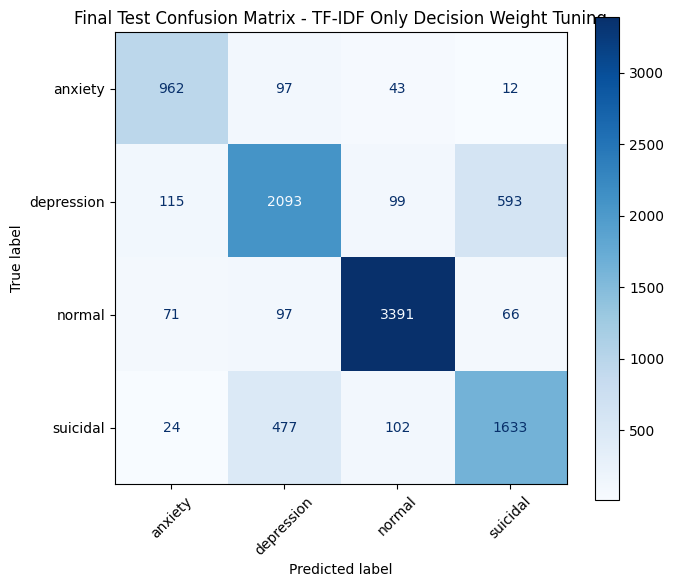

Saved final test confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1/figures/tfidf_stack_decision_weight_tfidf_lexicon_only_base_defaults_v1__final_test_confusion_matrix.png


In [ ]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    preds_test_final = predict_with_weights(
        proba_test,
        best_weights,
        class_list
    )

    f1_test = f1_score(
        y_test,
        preds_test_final,
        average="macro"
    )

    acc_test = accuracy_score(
        y_test,
        preds_test_final
    )

    print("\n==================================================")
    print(f"Meta Config          : {best_meta_config_name}")
    print(f"Val Macro F1         : {f1_val:.4f}")
    print(f"Final Test Accuracy  : {acc_test:.4f}")
    print(f"Final Test Macro F1  : {f1_test:.4f}")
    print("==================================================")

    print(
        classification_report(
            y_test,
            preds_test_final,
            digits=4,
            zero_division=0
        )
    )

    final_test_report_path = os.path.join(
        REPORT_DIR,
        f"{EXPERIMENT_NAME}__final_test_report.txt"
    )

    with open(final_test_report_path, "w", encoding="utf-8") as f:
        f.write(f"FINAL TEST REPORT - {EXPERIMENT_NAME}\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Meta config: {best_meta_config_name}\n")
        f.write(f"Fixed meta class_weight: {best_candidate['meta_class_weight']}\n")
        f.write(f"Val Macro F1 used for selection: {f1_val:.4f}\n")
        f.write(f"Test Accuracy: {acc_test:.4f}\n")
        f.write(f"Test Macro F1: {f1_test:.4f}\n\n")
        f.write(f"Best decision weights: {weight_dict}\n\n")
        f.write(
            classification_report(
                y_test,
                preds_test_final,
                digits=4,
                zero_division=0
            )
        )

    print("Saved final test report:", final_test_report_path)

    cm_test = confusion_matrix(
        y_test,
        preds_test_final,
        labels=class_list
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=class_list
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
    plt.title(f"Final Test Confusion Matrix - TF-IDF Only Decision Weight Tuning")
    plt.tight_layout()

    test_cm_path = os.path.join(
        FIGURE_DIR,
        f"{EXPERIMENT_NAME}__final_test_confusion_matrix.png"
    )

    plt.savefig(test_cm_path, dpi=200)
    plt.show()

    print("Saved final test confusion matrix:", test_cm_path)

else:
    print("RUN_FINAL_TEST = False")
    print("Không đánh giá test trong giai đoạn tuning.")
    print("Chỉ bật RUN_FINAL_TEST=True sau khi đã chọn config bằng validation.")

In [ ]:

import time
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report


INFERENCE_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_report.json"
)

INFERENCE_SUMMARY_CSV_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_summary.csv"
)


def build_meta_features_for_inference(df_enriched, fold_bundles, base_model_names, class_names):

    required_cols = ["cleaned_text"] + list(LEXICON_FEATURES)
    missing_cols = [col for col in required_cols if col not in df_enriched.columns]
    if missing_cols:
        raise ValueError(
            "df_enriched is missing required columns: " + ", ".join(missing_cols)
        )

    fold_meta_features = []

    for fold_idx, fold_bundle in enumerate(fold_bundles, start=1):
        feature_pipeline = fold_bundle["feature_pipeline"]
        models = fold_bundle["models"]

        X_fe = transform_with_feature_pipeline(
            df_enriched,
            feature_pipeline
        )

        meta_parts = []

        for model_name in base_model_names:
            model = models[model_name]

            proba = aligned_predict_proba(
                model,
                X_fe,
                class_names
            )

            meta_parts.append(proba)

        fold_meta = np.hstack(meta_parts)
        fold_meta_features.append(fold_meta)

    averaged_meta_features = np.mean(fold_meta_features, axis=0)

    return averaged_meta_features


def predict_from_meta_features_with_timing(X_meta):
    start_time = time.perf_counter()

    proba = meta_model.predict_proba(X_meta)
    preds = predict_with_weights(
        proba,
        best_weights,
        class_list
    )

    total_time = time.perf_counter() - start_time
    return preds, proba, total_time


def predict_enriched_pipeline_with_timing(df_enriched):

    start_time = time.perf_counter()

    X_meta = build_meta_features_for_inference(
        df_enriched=df_enriched,
        fold_bundles=fold_bundles,
        base_model_names=base_model_names,
        class_names=class_names
    )

    proba = meta_model.predict_proba(X_meta)

    preds = predict_with_weights(
        proba,
        best_weights,
        class_list
    )

    total_time = time.perf_counter() - start_time

    return preds, proba, X_meta, total_time


def predict_raw_text_pipeline_with_timing(df_raw):

    start_time = time.perf_counter()

    df_enriched = prepare_tfidf_lexicon_dataframe(df_raw)

    X_meta = build_meta_features_for_inference(
        df_enriched=df_enriched,
        fold_bundles=fold_bundles,
        base_model_names=base_model_names,
        class_names=class_names
    )

    proba = meta_model.predict_proba(X_meta)

    preds = predict_with_weights(
        proba,
        best_weights,
        class_list
    )

    total_time = time.perf_counter() - start_time

    return preds, proba, X_meta, total_time



warmup_n = min(10, len(test_enriched))

if warmup_n > 0:
    _ = predict_enriched_pipeline_with_timing(
        test_enriched.iloc[:warmup_n].copy()
    )
    _ = predict_raw_text_pipeline_with_timing(
        test_raw.iloc[:warmup_n].copy()
    )

print(f"Warm-up completed on {warmup_n} samples.")




preds_test_enriched_timed, proba_test_enriched_timed, X_meta_test_timed, enriched_pipeline_time = (
    predict_enriched_pipeline_with_timing(
        test_enriched.copy()
    )
)

enriched_pipeline_time_per_sample = enriched_pipeline_time / len(test_enriched)




preds_test_raw_timed, proba_test_raw_timed, X_meta_test_raw_timed, raw_text_pipeline_time = (
    predict_raw_text_pipeline_with_timing(
        test_raw.copy()
    )
)

raw_text_pipeline_time_per_sample = raw_text_pipeline_time / len(test_raw)



preds_test_meta_only, proba_test_meta_only, meta_model_only_time = predict_from_meta_features_with_timing(
    X_meta_test_timed
)

meta_model_only_time_per_sample = meta_model_only_time / len(test_enriched)


if not np.array_equal(preds_test_enriched_timed, preds_test_raw_timed):
    print("WARNING: Predictions differ between enriched-dataframe pipeline and raw-text pipeline.")

if not np.array_equal(preds_test_enriched_timed, preds_test_meta_only):
    print("WARNING: Predictions differ between full enriched pipeline and meta-model-only timing.")

test_acc_timed = accuracy_score(y_test, preds_test_raw_timed)
test_macro_f1_timed = f1_score(y_test, preds_test_raw_timed, average="macro")

print("\n================ INFERENCE TIME REPORT ================")
print(f"Number of test samples                         : {len(test_enriched)}")
print(f"Meta-model-only inference time                 : {meta_model_only_time:.6f} seconds")
print(f"Meta-model-only inference time per sample      : {meta_model_only_time_per_sample:.8f} seconds/sample")
print(f"Enriched-dataframe pipeline inference time     : {enriched_pipeline_time:.6f} seconds")
print(f"Enriched-dataframe pipeline time per sample    : {enriched_pipeline_time_per_sample:.8f} seconds/sample")
print(f"Raw-text pipeline inference time               : {raw_text_pipeline_time:.6f} seconds")
print(f"Raw-text pipeline inference time per sample    : {raw_text_pipeline_time_per_sample:.8f} seconds/sample")
print(f"Test Accuracy                                  : {test_acc_timed:.4f}")
print(f"Test Macro F1                                  : {test_macro_f1_timed:.4f}")
print("=======================================================")

print(
    classification_report(
        y_test,
        preds_test_raw_timed,
        digits=4,
        zero_division=0
    )
)



inference_report = {
    "experiment_name": EXPERIMENT_NAME,
    "measurement_type": "raw_text_pipeline_inference",
    "description": (
        "Main reported inference time starts from raw dataframe containing text, "
        "then creates cleaned_text and lexicon features, applies fold feature "
        "pipelines, runs base models, averages meta features, applies meta Logistic "
        "Regression, and applies tuned decision weights. Additional timing fields "
        "are saved for enriched-dataframe pipeline and meta-model-only inference."
    ),
    "n_test_samples": int(len(test_enriched)),

    "meta_model_only_inference_time_seconds": float(meta_model_only_time),
    "meta_model_only_inference_time_per_sample_seconds": float(meta_model_only_time_per_sample),

    "enriched_dataframe_pipeline_inference_time_seconds": float(enriched_pipeline_time),
    "enriched_dataframe_pipeline_inference_time_per_sample_seconds": float(enriched_pipeline_time_per_sample),

    "raw_text_pipeline_inference_time_seconds": float(raw_text_pipeline_time),
    "raw_text_pipeline_inference_time_per_sample_seconds": float(raw_text_pipeline_time_per_sample),

    # Backward-compatible aliases using the recommended report timing.
    "total_test_inference_time_seconds": float(raw_text_pipeline_time),
    "average_inference_time_per_sample_seconds": float(raw_text_pipeline_time_per_sample),

    "test_accuracy": float(test_acc_timed),
    "test_macro_f1": float(test_macro_f1_timed),
    "n_folds": int(len(fold_bundles)),
    "base_models": list(base_model_names),
    "class_list": [str(c) for c in class_list],
    "decision_weights": {
        str(cls): float(w)
        for cls, w in zip(class_list, best_weights)
    }
}

with open(INFERENCE_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_report, f, ensure_ascii=False, indent=2)

inference_summary_df = pd.DataFrame([
    {
        "experiment_name": EXPERIMENT_NAME,
        "measurement_type": "raw_text_pipeline_inference",
        "n_test_samples": len(test_enriched),
        "meta_model_only_inference_time_seconds": meta_model_only_time,
        "meta_model_only_inference_time_per_sample_seconds": meta_model_only_time_per_sample,
        "enriched_dataframe_pipeline_inference_time_seconds": enriched_pipeline_time,
        "enriched_dataframe_pipeline_inference_time_per_sample_seconds": enriched_pipeline_time_per_sample,
        "raw_text_pipeline_inference_time_seconds": raw_text_pipeline_time,
        "raw_text_pipeline_inference_time_per_sample_seconds": raw_text_pipeline_time_per_sample,
        # Backward-compatible aliases using the recommended report timing.
        "total_inference_time_seconds": raw_text_pipeline_time,
        "inference_time_per_sample_seconds": raw_text_pipeline_time_per_sample,
        "test_accuracy": test_acc_timed,
        "test_macro_f1": test_macro_f1_timed,
    }
])

inference_summary_df.to_csv(
    INFERENCE_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved inference time report:")
print(INFERENCE_REPORT_PATH)

print("\nSaved inference time summary CSV:")
print(INFERENCE_SUMMARY_CSV_PATH)

display(inference_summary_df)



Warm-up completed on 10 samples.

================ INFERENCE TIME REPORT ================
Number of test samples                         : 9875
Meta-model-only inference time                 : 0.003024 seconds
Meta-model-only inference time per sample      : 0.00000031 seconds/sample
Enriched-dataframe pipeline inference time     : 29.032974 seconds
Enriched-dataframe pipeline time per sample    : 0.00294005 seconds/sample
Raw-text pipeline inference time               : 31.616160 seconds
Raw-text pipeline inference time per sample    : 0.00320164 seconds/sample
Test Accuracy                                  : 0.8181
Test Macro F1                                  : 0.8086
              precision    recall  f1-score   support

     anxiety     0.8208    0.8636    0.8416      1114
  depression     0.7572    0.7217    0.7391      2900
      normal     0.9329    0.9354    0.9342      3625
    suicidal     0.7088    0.7303    0.7194      2236

    accuracy                         0.8181    

,experiment_name,measurement_type,n_test_samples,meta_model_only_inference_time_seconds,meta_model_only_inference_time_per_sample_seconds,enriched_dataframe_pipeline_inference_time_seconds,enriched_dataframe_pipeline_inference_time_per_sample_seconds,raw_text_pipeline_inference_time_seconds,raw_text_pipeline_inference_time_per_sample_seconds,total_inference_time_seconds,inference_time_per_sample_seconds,test_accuracy,test_macro_f1
0,tfidf_stack_decision_weight_tfidf_lexicon_only...,raw_text_pipeline_inference,9875,0.003024,3.061786e-07,29.032974,0.00294,31.61616,0.003202,31.61616,0.003202,0.818127,0.80856


In [ ]:

import os
import json
import joblib
import numpy as np

PACKAGE_DIR = "/content/drive/MyDrive/CS114/TeamModel/demo_model"
os.makedirs(PACKAGE_DIR, exist_ok=True)

PACKAGE_PATH = os.path.join(
    PACKAGE_DIR,
    "tfidf_stacking_tfidf_lexicon_only_decision_weight_tuned_demo_bundle.joblib"
)


required_vars = [
    "fold_bundles",
    "meta_model",
    "class_list",
    "best_weights",
    "weight_dict",
    "best_meta_config_name",
    "EXPERIMENT_NAME"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Thiếu các biến cần thiết để đóng gói model: {missing_vars}. "
        "Hãy chạy xong phần train/load base models và tune/load meta LR trước."
    )

print("All required variables are available.")


if "best_candidate" in globals() and isinstance(best_candidate, dict):
    best_meta_class_weight = best_candidate.get(
        "meta_class_weight",
        str(getattr(meta_model, "class_weight", None))
    )
else:
    best_meta_class_weight = str(getattr(meta_model, "class_weight", None))

class_list_arr = np.array(class_list)

class_decision_weights_array = np.array(best_weights, dtype=np.float32)

class_decision_weights_array = np.array(
    [
        float(weight_dict[cls])
        for cls in class_list_arr
    ],
    dtype=np.float32
)

print("Class list:", class_list_arr)
print("Decision weights:", class_decision_weights_array)
print("Weight dict:", weight_dict)




demo_bundle = {
    "experiment_name": EXPERIMENT_NAME,


    "fold_bundles": fold_bundles,

    "meta_model": meta_model,

    "class_list": class_list_arr,

    "class_decision_weights": class_decision_weights_array,
    "class_decision_weights_dict": weight_dict,

    "best_meta_config_name": best_meta_config_name,
    "best_meta_class_weight": str(best_meta_class_weight),

    "n_splits": N_SPLITS if "N_SPLITS" in globals() else None,
    "feature_k": FEATURE_K if "FEATURE_K" in globals() else None,
    "word_ngram_range": WORD_NGRAM_RANGE if "WORD_NGRAM_RANGE" in globals() else None,
    "char_analyzer": CHAR_ANALYZER if "CHAR_ANALYZER" in globals() else None,
    "char_ngram_range": CHAR_NGRAM_RANGE if "CHAR_NGRAM_RANGE" in globals() else None,

    "note": (
        "TF-IDF only stacking model bundle with fixed balanced meta Logistic Regression. "
        "Only class decision weights are tuned on validation. "
        "No handcrafted/manual numeric features are used. "
        "Includes fold bundles, fixed meta model, and tuned class decision weights."
    )
}

joblib.dump(demo_bundle, PACKAGE_PATH)

print("\nSaved full tuned demo model bundle:")
print(PACKAGE_PATH)

All required variables are available.
Class list: ['anxiety' 'depression' 'normal' 'suicidal']
Decision weights: [1.   1.2  0.9  1.15]
Weight dict: {'anxiety': 1.0, 'depression': 1.2000000476837158, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}

Saved full tuned demo model bundle:
/content/drive/MyDrive/CS114/TeamModel/demo_model/tfidf_stacking_tfidf_lexicon_only_decision_weight_tuned_demo_bundle.joblib
